<a href="https://colab.research.google.com/github/sechan-design/2026-data-science-and-machine-learning/blob/main/ARIMAX_%EB%AA%A8%EB%8D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
install.packages("forecast")
library(forecast)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [12]:
data <- read.csv("통합데이터.csv") #파일명 치기

In [13]:
y <- ts(data$whole)
x1 <- data$whole_popu
x2 <- data$cpi
x_multi <- cbind(x1,x2)

In [14]:
# ARIMAX
model <- auto.arima(y, xreg = x_multi)
summary(model)

Series: y 
Regression with ARIMA(1,0,0) errors 

Coefficients:
         ar1  intercept      x2
      0.8422   -29.8709  0.6332
s.e.  0.1125    12.0561  0.1207

sigma^2 = 4.028:  log likelihood = -39.18
AIC=86.36   AICc=89.22   BIC=90.14

Training set error measures:
                     ME     RMSE      MAE       MPE     MAPE      MASE
Training set -0.1840307 1.841639 1.510123 -1.295149 5.050359 0.8547865
                    ACF1
Training set -0.01778752


	Ljung-Box test

data:  Residuals from Regression with ARIMA(1,0,0) errors
Q* = 6.4866, df = 3, p-value = 0.09019

Model df: 1.   Total lags used: 4



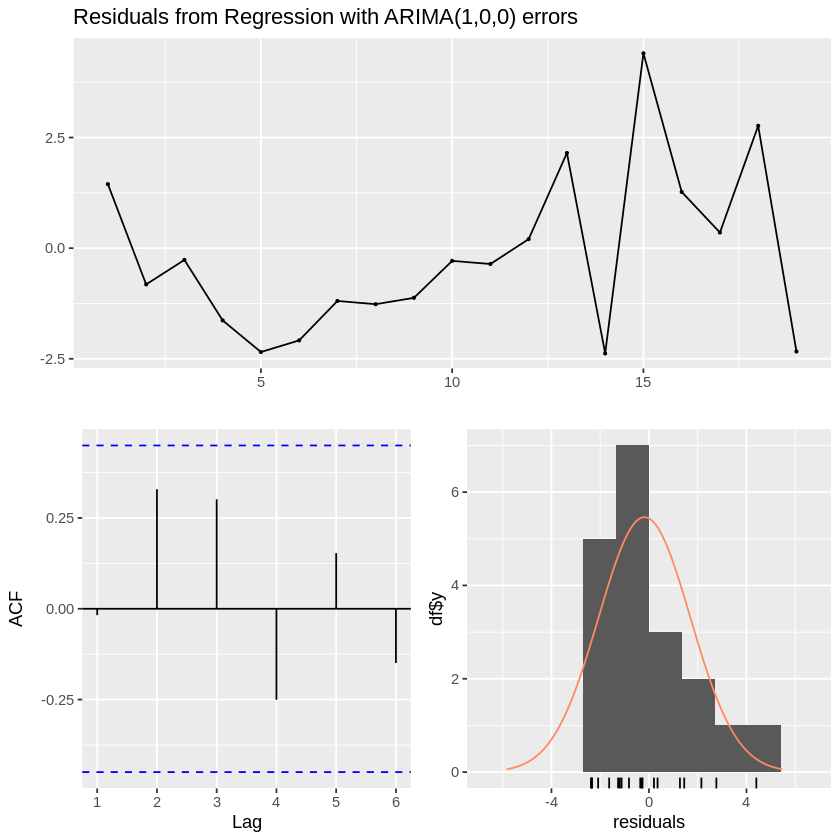

In [15]:
# 잔차 확인
checkresiduals(model)

In [16]:
# 차분 ARIMAX
dy <- diff(y)
dx1 <- diff(x1)
dx2 <- diff(x2)

dx_multi <- cbind(dx1,dx2)

model_diff <- auto.arima(dy, xreg = dx_multi)
summary(model_diff)

Series: dy 
Regression with ARIMA(0,0,0) errors 

Coefficients:
         dx2
      0.6018
s.e.  0.1829

sigma^2 = 3.956:  log likelihood = -37.4
AIC=78.81   AICc=79.61   BIC=80.59

Training set error measures:
                     ME     RMSE      MAE  MPE MAPE      MASE        ACF1
Training set 0.02068293 1.933018 1.488986 -Inf  Inf 0.8409557 -0.09085186

In [18]:
# 회귀 비교
lm_model <- lm(y ~ x1+x2)
summary(lm_model)

ERROR: Error in model.frame.default(formula = y ~ x1 + x2, drop.unused.levels = TRUE): invalid type (NULL) for variable 'x1'
